# TP2 - Etapa 2 en Google Colab: dataset, preprocesamiento, entrenamiento y comparacion de modelos

Notebook de trabajo de la Etapa 2: analisis del dataset, preprocesamiento, fine-tuning de
ResNet18 (Modelo A, obligatorio), CNN propia (Modelo B, opcional) y estudio comparativo.

El entrenamiento se realiza en Colab para aprovechar la GPU:
**Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU (T4)**.

Requisitos previos (en tu fork):
- `train_classifier`, `evaluate_classifier` y `extract_custom_embedding` implementadas
  en `src/lib/services/classifier_service.py` (esta notebook solo las orquesta).

Al finalizar:
- Descargar los checkpoints generados y colocarlos en `models/` de tu entorno local
  (la aplicacion los usa en las pestañas Etapa 1 y 2 del frontend).
- Publicarlos en un link de solo lectura publico para los docentes.
- Entregar esta notebook ejecutada, con sus salidas.

## Equipo
- Alumno 1 :
- Alumno 2 :

## 1. Clonar el repositorio

Si tu fork es privado, genera un token de acceso (GitHub -> Settings -> Developer settings ->
Personal access tokens) y usalo en la URL, o sube un zip del proyecto a Colab/Drive.

In [5]:
try:
    import google.colab
    colab = True
except ImportError:
    colab = False

if colab:
    REPO_URL = "https://github.com/nicoomancini/tuia-dog-recognition-app"

    import os
    if not os.path.exists("proyecto"):
        !git clone $REPO_URL proyecto
        %cd proyecto
    else:
        %cd proyecto

/content/proyecto


## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv, numpy, scikit-learn y matplotlib;
solo se instala lo que falta.

In [35]:
#!pip install -r requirements-etapas.txt

In [2]:
#!pip install -q pydantic-settings python-dotenv kagglehub albumentations onnxruntime torch torchvision

## 3. Configuracion del entorno

En Colab no hay PostgreSQL; la Etapa 2 no usa la base vectorial, por lo que se desactiva
pgvector. La configuracion se define por variables de entorno **antes** de importar `lib`.

In [6]:
# IMPORTS
import os
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import re
import sys
import seaborn as sns

# CONFIGURACIÓN GENERAL
#os.environ["USE_PGVECTOR"] = "False"
IMAGE_SIZE = 224

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lib.config import settings
from lib.bootstrap import build_classifier

# DISPOSITIVO
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SEMILLA
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# VERIFICACIÓN
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())
print("DEVICE:", DEVICE)

dataset_path: data/dataset
GPU disponible: True
DEVICE: cuda


## 4. Descargar el dataset

In [7]:
!python scripts/download_dataset.py

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Using Colab cache for faster access to the '70-dog-breedsimage-data-set' dataset.
Ya existe, se omite: /content/proyecto/data/dataset/valid
Ya existe, se omite: /content/proyecto/data/dataset/dogs.csv
Ya existe, se omite: /content/proyecto/data/dataset/test
Ya existe, se omite: /content/proyecto/data/dataset/train
Dataset disponible en /content/proyecto/data/dataset


In [8]:
DATASET_ROOT = Path("./data/dataset")

RUTA_TRAIN = DATASET_ROOT / "train"
RUTA_VAL   = DATASET_ROOT / "valid"
RUTA_TEST  = DATASET_ROOT / "test"

In [9]:
ext_img = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

X_train_paths, y_train_labels = [], []
X_val_paths,   y_val_labels   = [], []
X_test_paths,  y_test_labels  = [], []

def normalizar(nombre: str) -> str:
    return re.sub(r"\s+", "_", nombre.strip())

for split_ruta, X_paths, y_labels in [
    (RUTA_TRAIN, X_train_paths, y_train_labels),
    (RUTA_VAL,   X_val_paths,   y_val_labels),
    (RUTA_TEST,  X_test_paths,  y_test_labels),
]:
    for carpeta in split_ruta.iterdir():
        if not carpeta.is_dir():
            continue
        raza_norm = normalizar(carpeta.name)
        for f in carpeta.iterdir():
            if f.suffix.lower() in ext_img:
                X_paths.append(f)
                y_labels.append(raza_norm)

print(f"Train  : {len(X_train_paths):>5} imágenes")
print(f"Valid  : {len(X_val_paths):>5} imágenes")
print(f"Test   : {len(X_test_paths):>5} imágenes")

Train  :  7946 imágenes
Valid  :   700 imágenes
Test   :   700 imágenes


In [10]:
def contar_por_clase(labels):
    resultado = {}
    for label in labels:
        resultado[label] = resultado.get(label, 0) + 1
    return resultado

cnt_train = contar_por_clase(y_train_labels)

CLASES   = sorted(cnt_train.keys())
N_CLASES = len(CLASES)

total_tr = sum(cnt_train.values())

## 5. Preprocesamiento

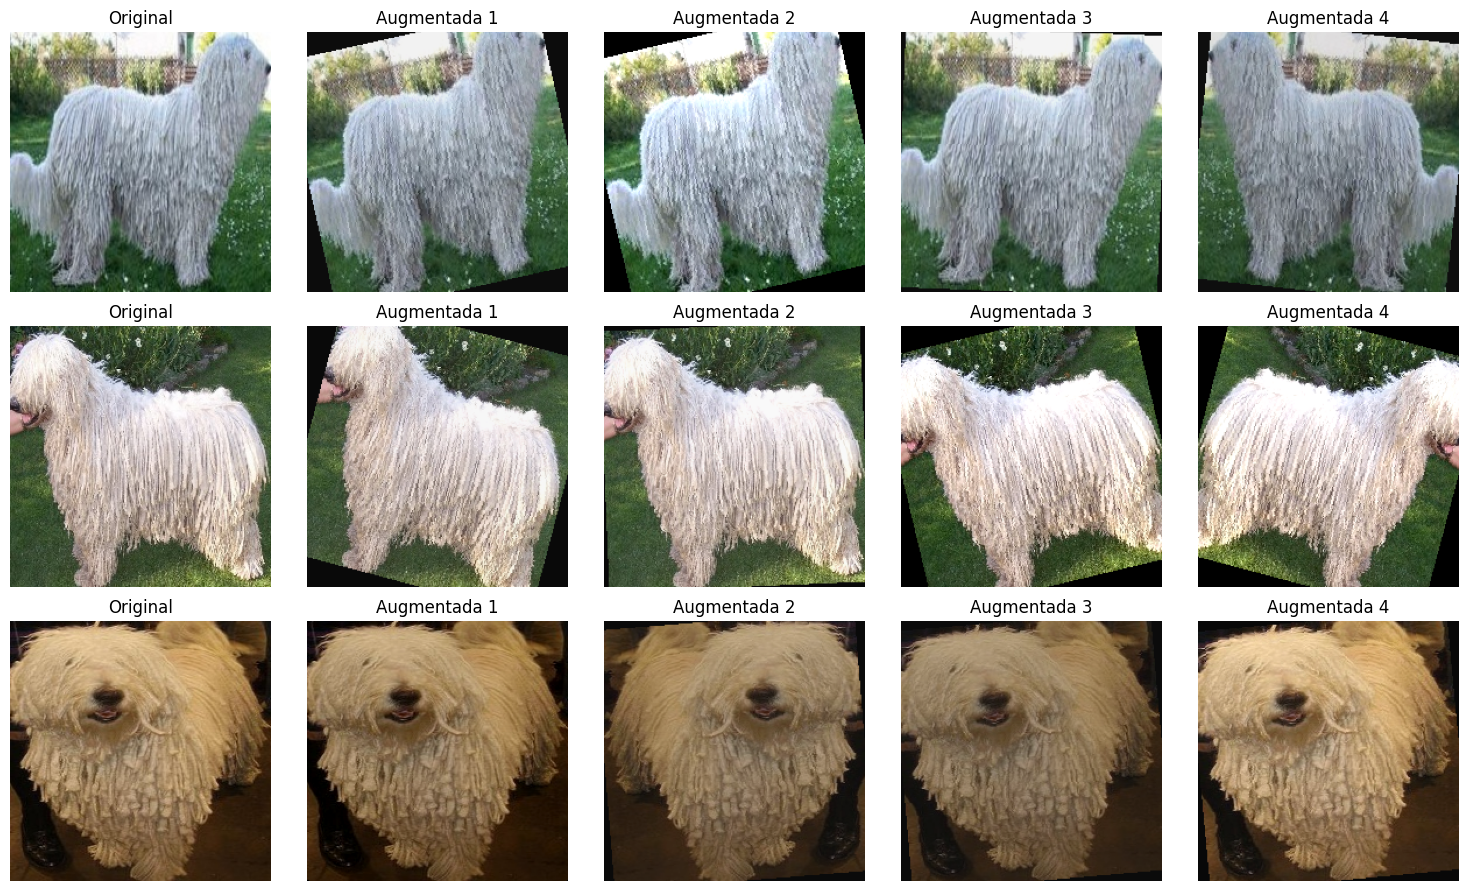

In [11]:
transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
])

# 3. Elegimos cuántas imágenes originales queremos ver y cuántas variaciones por imagen
muestras_paths = X_train_paths[:3] # Tomamos las primeras 3 de tu lista
num_variaciones = 4

# 4. Armamos el gráfico
fig, axes = plt.subplots(len(muestras_paths), num_variaciones + 1, figsize=(15, 3 * len(muestras_paths)))

for i, path in enumerate(muestras_paths):
    # Abrimos la imagen original usando PIL
    img_original = Image.open(path).convert('RGB')

    # Columna 1: Mostramos la original (solo redimensionada para comparar en igualdad)
    img_base = img_original.resize((IMAGE_SIZE, IMAGE_SIZE))
    axes[i, 0].imshow(img_base)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    # Columnas siguientes: Mostramos las versiones con Data Augmentation
    for j in range(num_variaciones):
        # Cada vez que le pasamos la imagen a viz_transform, PyTorch aplica
        # las transformaciones aleatorias generando una versión nueva
        img_aug = transform(img_original)

        axes[i, j + 1].imshow(img_aug)
        axes[i, j + 1].set_title(f"Augmentada {j+1}")
        axes[i, j + 1].axis("off")

plt.tight_layout()
plt.show()

## 6. Funciones adicionales

In [12]:
def plot_training_curves(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # Gráfico de Pérdida (Loss)
    ax1.plot(epochs, history['train_loss'], 'b-', marker='o', label='Train Loss')
    ax1.set_title(f'Pérdida durante el Entrenamiento - {model_name}')
    ax1.set_xlabel('Épocas')
    ax1.set_ylabel('Loss')
    ax1.grid(True)

    # Gráfico de Accuracy
    ax2.plot(epochs, history['val_acc'], 'g-', marker='o', label='Validation Accuracy')
    ax2.set_title(f'Precisión (Accuracy) - {model_name}')
    ax2.set_xlabel('Épocas')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [13]:
def plot_confusion_matrix(metrics_dict, classes_list):
    cm = np.array(metrics_dict["confusion_matrix"], dtype=float)

    # TRUCO 1: Apagamos la diagonal principal (aciertos) poniéndola en NaN
    # Esto hace que el mapa de calor solo coloree los errores.
    np.fill_diagonal(cm, np.nan)

    plt.figure(figsize=(16, 14)) # Agrandamos un poco el lienzo

    # Usamos un mapa de colores cálidos (ej: 'Reds') para que los errores resalten como alertas
    sns.heatmap(cm, annot=False, cmap='Reds', xticklabels=classes_list, yticklabels=classes_list)

    plt.title('Matriz de Confusión (Excluyendo Aciertos - Solo Errores)')
    plt.ylabel('Etiqueta Verdadera')
    plt.xlabel('Etiqueta Predicha')
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

    # TRUCO 2: Imprimir un top de las peores confusiones en texto plano
    # A veces leer el texto es más rápido que mirar 70 filas
    print("\n--- Top 5 Peores Confusiones ---")
    cm_zeroed = np.nan_to_num(cm) # Volvemos los NaN a 0 para buscar el máximo
    for _ in range(5):
        if cm_zeroed.max() == 0: break
        # Buscamos la coordenada del error más grande
        i, j = np.unravel_index(cm_zeroed.argmax(), cm_zeroed.shape)
        cantidad_errores = int(cm_zeroed[i, j])
        print(f"El modelo confundió {cantidad_errores} veces un '{classes_list[i]}' con un '{classes_list[j]}'")
        cm_zeroed[i, j] = 0 # Lo borramos para buscar el siguiente

In [14]:
def comparar_modelos(metrics_a, metrics_b, name_a="ResNet18", name_b="CNN Custom"):
    # Filtramos para no graficar la matriz de confusión acá
    labels = ['accuracy', 'precision', 'recall', 'specificity', 'f1']
    valores_a = [metrics_a[k] for k in labels]
    valores_b = [metrics_b[k] for k in labels]

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    rects1 = ax.bar(x - width/2, valores_a, width, label=name_a, color='royalblue')
    rects2 = ax.bar(x + width/2, valores_b, width, label=name_b, color='darkorange')

    ax.set_ylabel('Score')
    ax.set_title('Comparación de Métricas entre Modelos')
    ax.set_xticks(x)
    ax.set_xticklabels([l.capitalize() for l in labels])
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

## 7. Fine-tuning de ResNet18

`train_classifier` debe guardar el checkpoint en `models/resnet18_finetuned.pth`
(o el nombre configurado en RESNET18_MODEL_NAME). Documentar los hiperparametros
utilizados (learning rate, batch size, epochs, optimizador, scheduler).

In [15]:
classifier = build_classifier(settings)
classifier.set_active_model("resnet18_finetuned")

In [16]:
history_resnet = classifier.train_classifier()

Epoch 1/20 [Train]:   0%|          | 0/249 [00:00<?, ?it/s]

Epoch 1/20 [Valid]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 2/20 [Train]:   0%|          | 0/249 [00:00<?, ?it/s]

Epoch 2/20 [Valid]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 3/20 [Train]:   0%|          | 0/249 [00:00<?, ?it/s]

...

Epoch 9/20 [Valid]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 10/20 [Train]:   0%|          | 0/249 [00:00<?, ?it/s]

Epoch 10/20 [Valid]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 11/20 [Train]:   0%|          | 0/249 [00:00<?, ?it/s]

Epoch 11/20 [Valid]:   0%|          | 0/22 [00:00<?, ?it/s]

### Curvas de entrenamiento y matriz de confusión


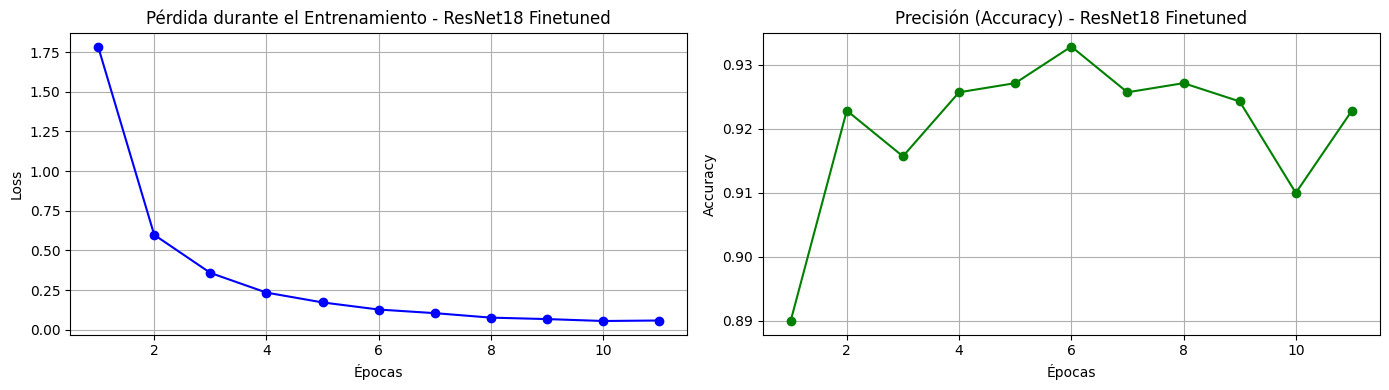

In [17]:
plot_training_curves(history_resnet, "ResNet18 Finetuned")

Evaluando modelo:   0%|          | 0/22 [00:00<?, ?it/s]

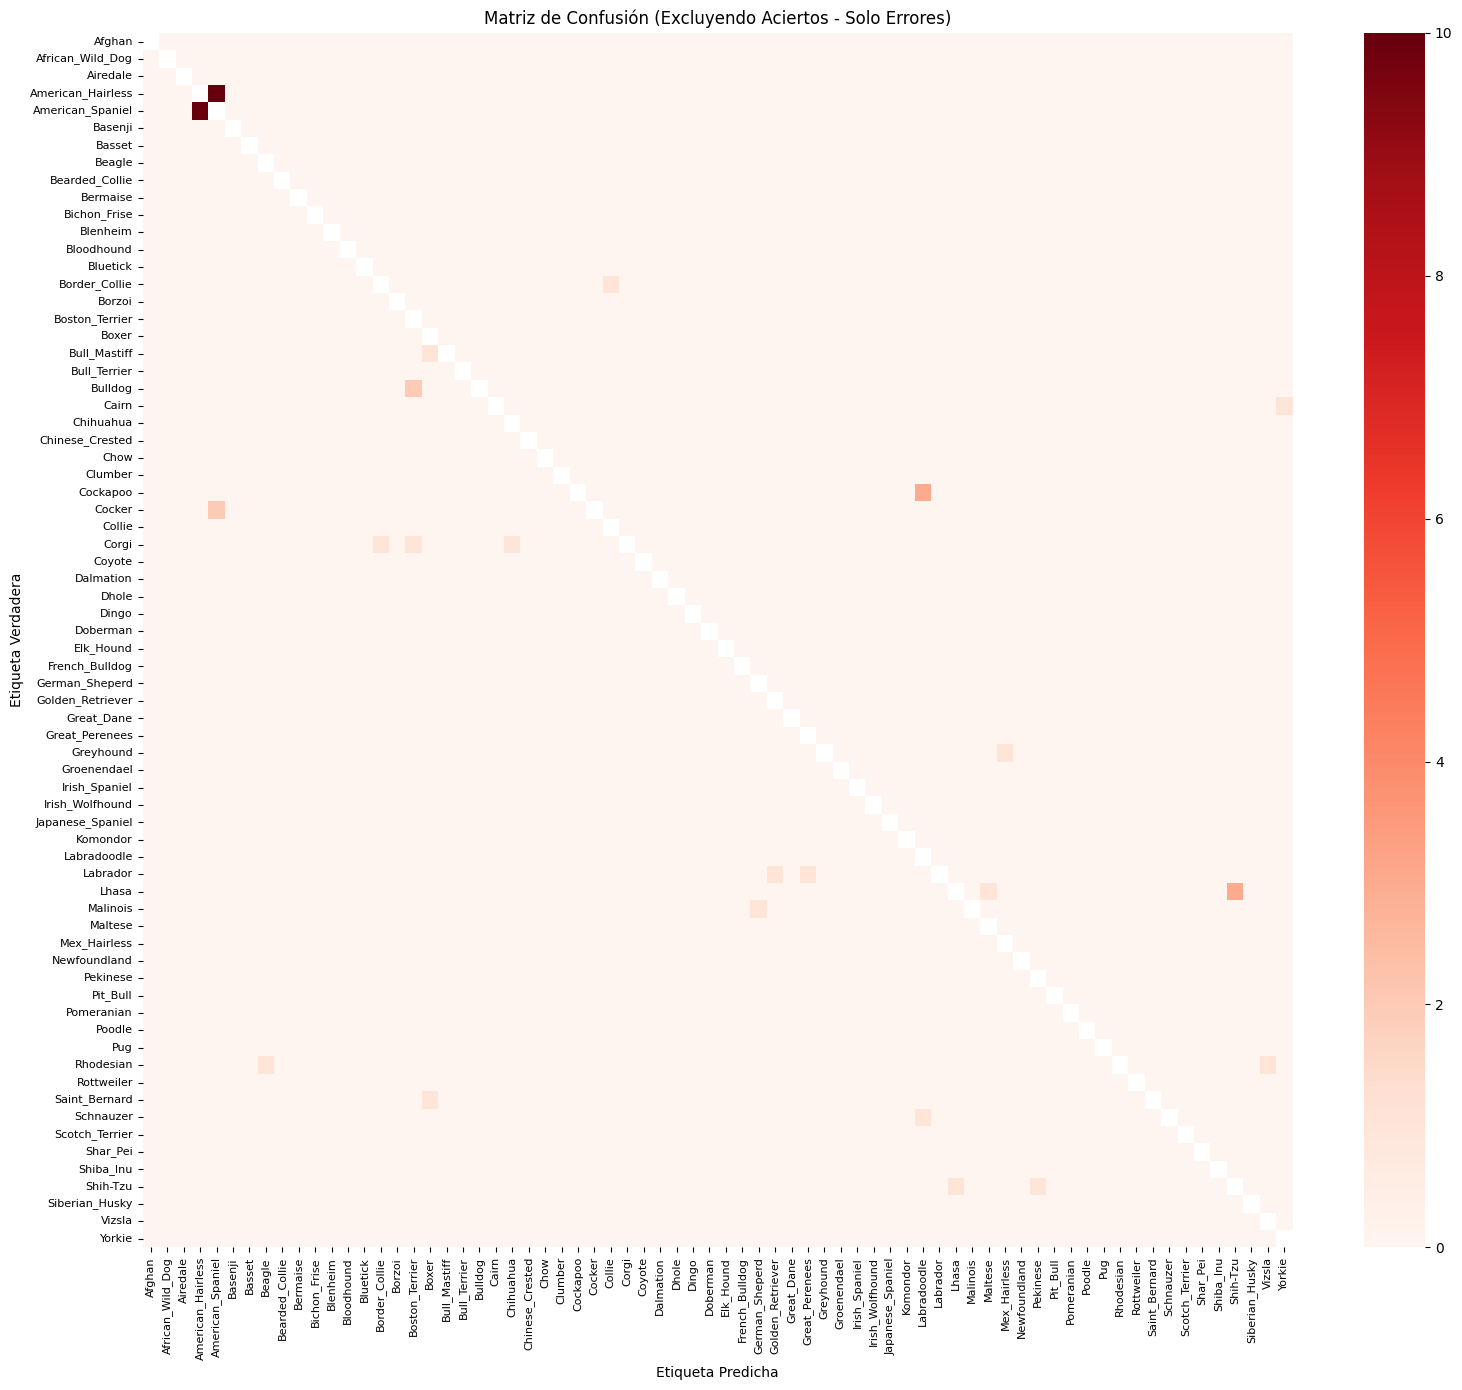


--- Top 5 Peores Confusiones ---
El modelo confundió 10 veces un 'American_Hairless' con un 'American_Spaniel'
El modelo confundió 10 veces un 'American_Spaniel' con un 'American_Hairless'
El modelo confundió 3 veces un 'Cockapoo' con un 'Labradoodle'
El modelo confundió 3 veces un 'Lhasa' con un 'Shih-Tzu'
El modelo confundió 2 veces un 'Bulldog' con un 'Boston_Terrier'


In [18]:
metricas_resnet = classifier.evaluate_classifier()
plot_confusion_matrix(metricas_resnet, CLASES)

## 8. CNN custom

`train_classifier` con el modelo activo `cnn_custom` debe guardar el checkpoint en
`models/cnn_custom.pth` (o el nombre configurado en CNN_CUSTOM_MODEL_NAME).

In [19]:
classifier.set_active_model("cnn_custom")
history_cnn = classifier.train_classifier()

Epoch 1/20 [Train]:   0%|          | 0/249 [00:00<?, ?it/s]

Epoch 1/20 [Valid]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 2/20 [Train]:   0%|          | 0/249 [00:00<?, ?it/s]

Epoch 2/20 [Valid]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 3/20 [Train]:   0%|          | 0/249 [00:00<?, ?it/s]

...

Epoch 18/20 [Valid]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 19/20 [Train]:   0%|          | 0/249 [00:00<?, ?it/s]

Epoch 19/20 [Valid]:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 20/20 [Train]:   0%|          | 0/249 [00:00<?, ?it/s]

Epoch 20/20 [Valid]:   0%|          | 0/22 [00:00<?, ?it/s]

### Curvas de entrenamiento y matriz de confusión

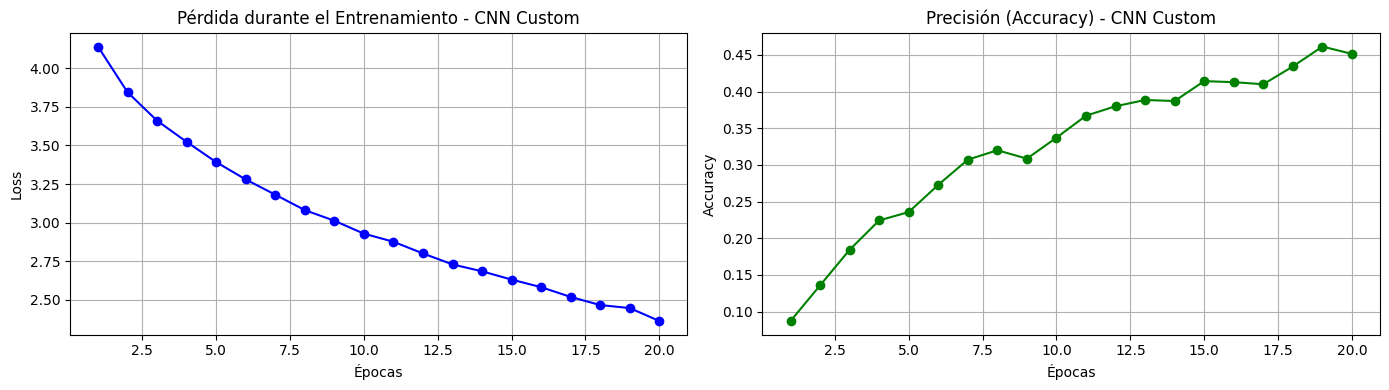

In [23]:
plot_training_curves(history_cnn, "CNN Custom")

Evaluando modelo:   0%|          | 0/22 [00:00<?, ?it/s]

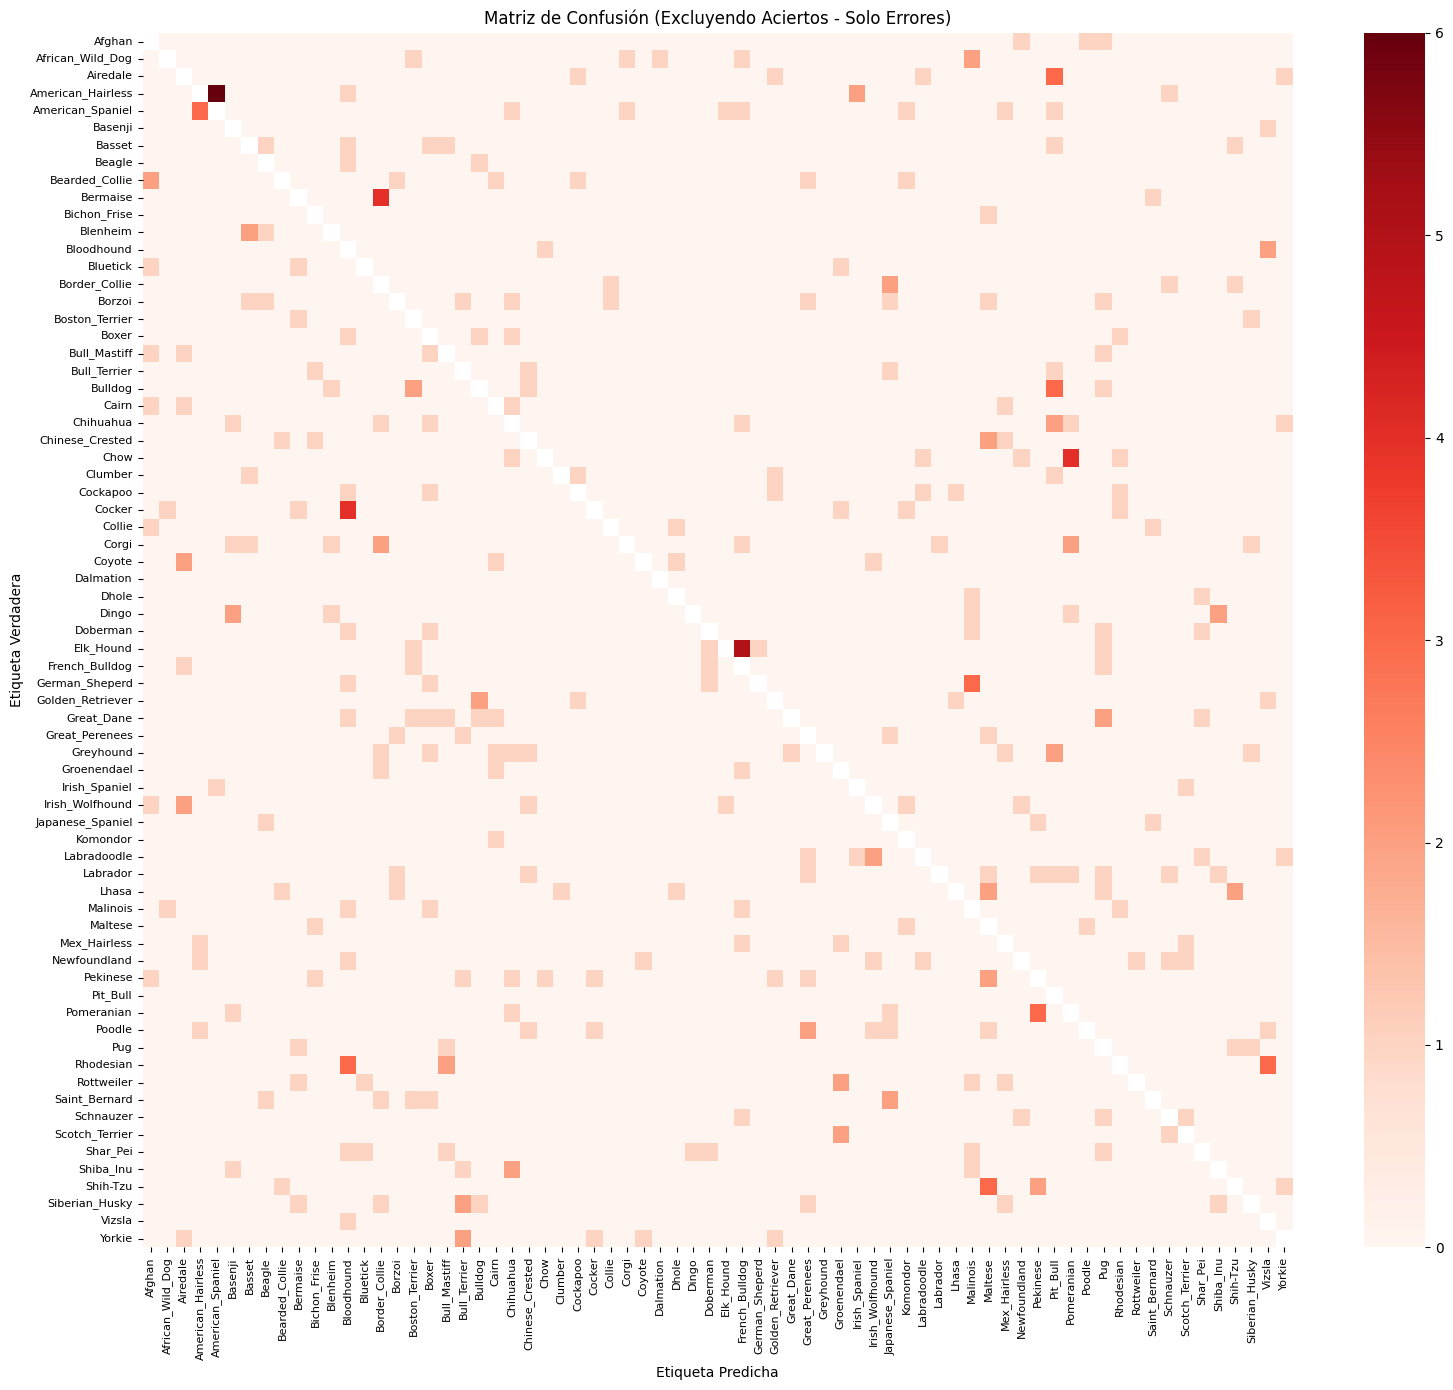


--- Top 5 Peores Confusiones ---
El modelo confundió 6 veces un 'American_Hairless' con un 'American_Spaniel'
El modelo confundió 5 veces un 'Elk_Hound' con un 'French_Bulldog'
El modelo confundió 4 veces un 'Bermaise' con un 'Border_Collie'
El modelo confundió 4 veces un 'Chow' con un 'Pomeranian'
El modelo confundió 4 veces un 'Cocker' con un 'Bloodhound'


In [24]:
metricas_cnn = classifier.evaluate_classifier()
plot_confusion_matrix(metricas_cnn, CLASES)

## 9. Estudio comparativo

TO-DO (pequeño estudio de la Etapa 2):
- Comparar los modelos entrenados: accuracy, precision, recall, specificity, F1.
- Analizar las clases con peor desempeño (falsos positivos / falsos negativos).
- Discutir trade-offs (performance vs costo computacional).
- Copiar las conclusiones al informe (`informe.ipynb`).

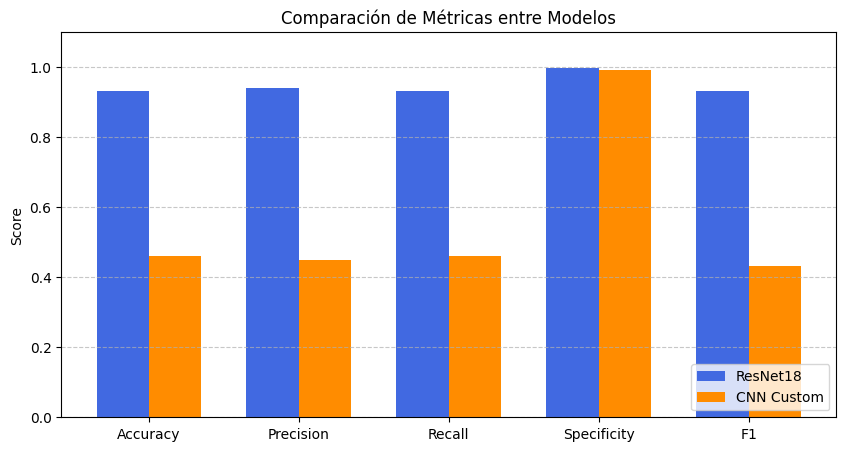

In [25]:
comparar_modelos(metricas_resnet, metricas_cnn)

## 10. Descargar los checkpoints

Descargalos y colocalos en `models/` de tu entorno local para que la aplicacion los use
(pestañas Etapa 1 y 2 del frontend). Recorda publicarlos en un link de solo lectura publico.

In [ ]:
"""
!ls -lh models/

try:
    from google.colab import files

    files.download(str(settings.model_path / settings.resnet18_model_name))
    # files.download(str(settings.model_path / settings.cnn_custom_model_name))
except ImportError:
    print("Fuera de Colab: los checkpoints quedan en models/")
"""

total 56M
-rw-r--r-- 1 root root 13M Jun 25 22:12 cnn_custom.pth
-rw-r--r-- 1 root root 43M Jun 25 21:54 resnet18_finetuned.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>